Task 1: Logistic Regression with a Single Feature

1. Data Retrieval and Collection 

In [33]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)


In [34]:
#Load datasets
data= pd.read_csv("dataset/Heart_Disease_Prediction.csv")
data.head()
data.tail()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence
269,67,1,4,160,286,0,2,108,1,1.5,2,3,3,Presence


In [35]:
#Dataset shape and columns

print("Shape:", data.shape)
print("Columns:", data.columns)


Shape: (270, 14)
Columns: Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')


The Heart Disease dataset contains medical attributes related to cardiovascular health.
Each row represents a patient, and the target variable indicates whether heart disease is present.


2.Data Cleaning

In [36]:
#Checking Missing Value
data.isna().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [37]:
# Handle missing cholesterol values if present 
data['Cholesterol'] = data['Cholesterol'].fillna(data['Cholesterol'].median())


In [38]:
# Ensuring target is binary
data['Heart Disease'].value_counts()


Heart Disease
Absence     150
Presence    120
Name: count, dtype: int64

In [39]:
# Verify data types
data.dtypes


Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease               object
dtype: object

3. Feature Design (Single Feature)

In [40]:
# Encode target variable to numeric
data['Heart Disease'] = data['Heart Disease'].map({
    'Absence': 0,
    'Presence': 1
})

In [41]:
X = data[['Cholesterol']]
y = data['Heart Disease']
print("Feature shape:", X.shape)
print("Target distribution", y.value_counts(normalize=True))


Feature shape: (270, 1)
Target distribution Heart Disease
0    0.555556
1    0.444444
Name: proportion, dtype: float64


Cholesterol is selected as the single input feature because high cholesterol
is a well-known risk factor for cardiovascular diseases.


4. Algorithm Selection 

Logistic Regression is chosen because it is specifically designed for binary
classification problems and outputs probabilities between 0 and 1. It is simple, interpretable, and effective for linearly separable problems.


5. Loss Function Selection 

Binary Cross-Entropy (Log Loss) is used as the loss function. It measures the difference between predicted probabilities and actual labels. It penalizes confident wrong predictions heavily, encouraging well-calibrated probabilities.


6. Model Training 

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_single = LogisticRegression()
model_single.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


The model learns coefficients and intercepts by minimizing the log loss using
gradient-based optimization. 


7. Model Evaluation 

In [43]:
y_pred = model_single.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6111111111111112
Precision: 0.5
Recall: 0.23809523809523808
F1 Score: 0.3225806451612903

Confusion Matrix:
 [[28  5]
 [16  5]]

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.85      0.73        33
           1       0.50      0.24      0.32        21

    accuracy                           0.61        54
   macro avg       0.57      0.54      0.52        54
weighted avg       0.58      0.61      0.57        54



* Accuracy: 0.61

The model correctly predicts 61% of cases overall.

Since we are using only cholesterol as a feature, this is expected — it captures some signal, but not enough for high accuracy.

* Precision: 0.50 (for Heart Disease = 1)

Of all the patients predicted to have heart disease, 50% were correct.

Moderate precision → the model is mistakenly predicting disease in some healthy patients.


* Recall: 0.24

Of all actual patients with heart disease, the model only correctly identified 24%.

Very low → single feature misses many patients with disease.

* F1 Score: 0.32

F1 is the harmonic mean of precision and recall.

Low F1 confirms the single-feature model is weak at detecting heart disease.

* Confusion Matrix
- True Negatives (TN) = 28 → correctly predicted no disease

- False Positives (FP) = 5 → predicted disease, actually healthy

- False Negatives (FN) = 16 → predicted healthy, actually disease

- True Positives (TP) = 5 → correctly predicted disease

Observation: The single-feature model shows limited performance because cholesterol alone
cannot capture the complexity of heart disease.


Sigmoid Curve Plot

In [44]:

# Generate cholesterol values in the range of your dataset
cholesterol_min = X['Cholesterol'].min()
cholesterol_max = X['Cholesterol'].max()
cholesterol_range = np.linspace(cholesterol_min, cholesterol_max, 300).reshape(-1,1)

# Predict probabilities for each value in the range
probabilities = model_single.predict_proba(cholesterol_range)[:,1]

c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


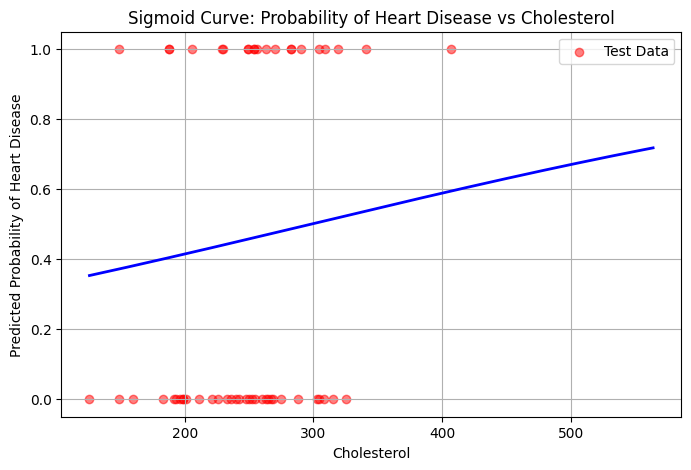

In [45]:
plt.figure(figsize=(8,5))
plt.plot(cholesterol_range, probabilities, color='blue', linewidth=2)
plt.scatter(X_test, y_test, color='red', alpha=0.5, label='Test Data')
plt.title('Sigmoid Curve: Probability of Heart Disease vs Cholesterol')
plt.xlabel('Cholesterol')
plt.ylabel('Predicted Probability of Heart Disease')
plt.legend()
plt.grid(True)
plt.show()


Blue curve: The sigmoid function learned by logistic regression.

Shows probability of heart disease between 0 and 1 for different cholesterol levels.

Red dots: Actual test data (0 = no disease, 1 = disease).

Observation: Higher cholesterol → higher predicted probability of heart disease.

Task 2: Logistic Regression with Multiple Features

1.Data Retrieval and Collection

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Load dataset
data = pd.read_csv("dataset/Heart_Disease_Prediction.csv")

print(data.shape)
print(data.columns)
data.head()


(270, 14)
Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


2. Data Cleaning 

In [47]:
# Encode target variable to numeric (0 = No disease, 1 = Disease)
data['Heart Disease'] = data['Heart Disease'].map({
    'Absence': 0,
    'Presence': 1
})

# Check for missing values
print(data.isna().sum())

# Handle missing values for numeric columns if any
numeric_cols = data.select_dtypes(include=np.number).columns
for col in numeric_cols:
    data.fillna(data.median(), inplace=True)


Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64


3. Features Design (Multiple Feature)

In [48]:
# Select all features except target
X = data.drop(columns=['Heart Disease'])
y = data['Heart Disease']

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Feature scaling 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Using all available features allows the model to capture more risk factors
for heart disease. Categorical variables are one-hot encoded, and numerical
features are standardized to ensure equal influence during model training.


4. Algorithm Selection
Logistic Regression is chosen because it is suitable for binary classification,
outputs probabilities, and allows interpretation of feature contributions via coefficients.


5. Loss Function Selection 
Binary Cross-Entropy (Log Loss) is used as the loss function. It penalizes 
wrong predictions proportionally to the confidence of the prediction, 
helping the model to adjust weights for better accuracy.


6. Model Training

In [49]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train logistic regression (increase max_iter to ensure convergence)
model_multi = LogisticRegression(max_iter=1000)
model_multi.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


The model learns coefficients for each feature by minimizing the log-loss
using gradient descent. Each coefficient indicates the influence of the
corresponding feature on the probability of having heart disease.


7. Model Evalaution 

Accuracy: 0.9074074074074074
Precision: 0.9
Recall: 0.8571428571428571
F1 Score: 0.8780487804878049

Confusion Matrix:
 [[31  2]
 [ 3 18]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.93        33
           1       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54



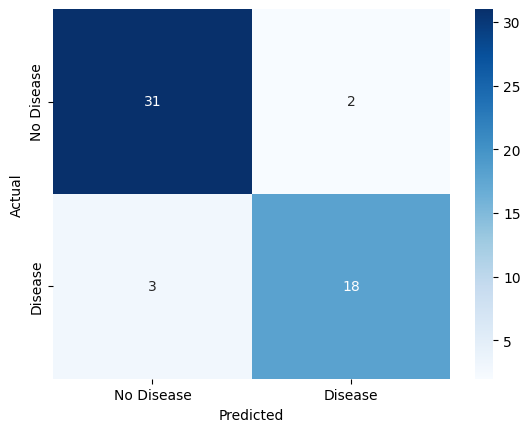

In [50]:
# Predict
y_pred = model_multi.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

#  visualize confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


The multi-feature logistic regression model shows improved performance 
over the single-feature model. 

* Accuracy: 0.91 

The model correctly predicts 91% of all patients.

Significant improvement over the single-feature model (61%).

Using multiple features captures more risk factors, improving overall predictions.

* Precision: 0.90 (for Heart Disease = 1)

Of all patients predicted to have heart disease, 90% actually have it.

This means the model has few false positives reliable positive predictions.

* Recall: 0.86

Of all actual patients with heart disease, 86% were correctly identified.

Huge improvement from Task 1 (24% recall).

Indicates that the model now detects most patients with heart disease.

* F1-Score: 0.88

Balanced measure between precision and recall.

Confirms that the model maintains high precision while improving recall.

Great indicator of overall performance for imbalanced datasets.

* Confusion Matrix

	          Predicted No  	Predicted Yes
Actual No	     TN = 31	   FP = 2
Actual Yes	     FN = 3	       TP = 18
- Only 3 patients with heart disease were missed (FN).

- Only 2 healthy patients were misclassified as diseased (FP).

* Classification Report

Confirms metrics for each class: 0 (No Disease) and 1 (Disease).

Both precision and recall are balanced for each class → well-performing model.

* Model Comparison

Metric	    Task 1 (Single Feature)	      Task 2 (Multiple Features)
Accuracy	0.61	                      0.91
Precision	0.50	                      0.90
Recall	    0.24	                       0.86
F1-Score	0.32	                      0.88



* Which Model Performs Better and Why?

Task 2 (Multiple Features) clearly performs better in all metrics: accuracy, precision, recall, and F1-score.

Task 1 used only cholesterol, which captures only part of the risk for heart disease. Task 2 uses all available features (age, blood pressure, cholesterol, etc.), which provides a more complete picture of patient risk.

More features allow the model to detect patterns that a single feature cannot capture, leading to higher accuracy and better detection of actual patients with disease.


*How Does Adding More Features Affect Accuracy and Recall?

- Accuracy: Increased from 61% → 91%

- Adding more features reduces misclassifications for both healthy and diseased patients.

- Recall: Increased from 24% → 86%

- Multi-feature model detects far more actual patients with heart disease.

- This is crucial in medical diagnosis, where missing a patient is dangerous.

- Including more relevant features allows the model to capture complex interactions that single-feature models miss.


* Trade-offs Between Interpretability and Performance

Aspect	            Single Feature	                                         Multiple Features
1.Interpretability	High – easy to explain the effect of cholesteral    – harder to explain all features 

2.Performance	        Low – misses many patients	               High – detects most patients accurately
3. Use Case Recommendation:	Simple scenarios, educational purposes	        Real-world medical diagnosis



Single-feature models are easier to understand: Higher cholesterol → higher risk.

Multi-feature models are more accurate but less interpretable: several features contribute, interactions are complex.

